# Stage 8 — Optional Normalization Experiment

Stage 8 kiểm tra normalization rule-based đơn giản có giúp phục hồi hiệu năng trên noisy input hay không.

Bản này chạy **baseline models local**. PhoBERT normalization evaluation có thể làm riêng trên Kaggle nếu thật sự cần.

Không train model mới.


## 1. Imports and project paths

In [2]:
from pathlib import Path
from datetime import datetime
import sys

import pandas as pd
import matplotlib.pyplot as plt
import yaml

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "08_optional_normalization_config.yaml"

from src.normalizer import (
    normalize_noisy_dataframe,
    load_label_mapping,
    discover_baseline_models,
    prepare_eval_frame,
    evaluate_sklearn_model,
    compute_normalization_improvement,
    summarize_normalized_generation,
)

print("Project root:", PROJECT_ROOT)
print("Config path:", CONFIG_PATH)


Project root: d:\project-ml-engineering\nlp-phobert-student-feedback
Config path: d:\project-ml-engineering\nlp-phobert-student-feedback\configs\08_optional_normalization_config.yaml


## 2. Load config, noisy data, and models

In [3]:
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Missing config: {CONFIG_PATH}")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

source_cfg = config["source"]
model_cfg = config["models"]
eval_cfg = config["evaluation"]
output_cfg = config["output"]

NOISY_DIR = PROJECT_ROOT / source_cfg["noisy_dir"]
NOISY_PATTERN = source_cfg.get("noisy_file_pattern", "04_test_*.csv")
LABEL_MAPPING_PATH = PROJECT_ROOT / source_cfg["label_mapping_path"]

NORMALIZED_DIR = PROJECT_ROOT / output_cfg["normalized_dir"]
TABLES_DIR = PROJECT_ROOT / output_cfg["reports_tables_dir"]
FIGURES_DIR = PROJECT_ROOT / output_cfg["reports_figures_dir"]
NOTES_DIR = PROJECT_ROOT / output_cfg["reports_notes_dir"]

for path in [NORMALIZED_DIR, TABLES_DIR, FIGURES_DIR, NOTES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

label_mapping = load_label_mapping(LABEL_MAPPING_PATH)

noisy_files = sorted(NOISY_DIR.glob(NOISY_PATTERN))
if not noisy_files:
    raise FileNotFoundError(f"No noisy files found in {NOISY_DIR} with pattern {NOISY_PATTERN}")

noisy_frames = {}
for path in noisy_files:
    df = pd.read_csv(path)
    noise_type = str(df["noise_type"].iloc[0]) if "noise_type" in df.columns and len(df) else path.stem.replace("04_test_", "")
    noisy_frames[noise_type] = df
    print(f"Loaded {noise_type}: {df.shape}")

tasks = eval_cfg.get("tasks", ["sentiment", "topic"])
baseline_root = PROJECT_ROOT / model_cfg["baseline_root"]
fallback_roots = [PROJECT_ROOT / item for item in model_cfg.get("baseline_fallback_roots", [])]

model_specs = []
for task in tasks:
    specs = discover_baseline_models(task, baseline_root, fallback_roots)
    if not specs:
        print(f"[WARNING] No baseline models found for task={task}")
    model_specs.extend(specs)

if not model_specs:
    raise FileNotFoundError("No baseline models found.")

models_df = pd.DataFrame([
    {
        "task": spec["task"],
        "model_type": spec["model_type"],
        "model_name": spec["model_name"],
        "path": str(spec["path"]),
    }
    for spec in model_specs
])

display(models_df)


Loaded domain_abbreviation: (3166, 15)
Loaded elongation: (3166, 15)
Loaded mixed_noise: (3166, 15)
Loaded no_accent: (3166, 15)
Loaded teencode_colloquial: (3166, 15)
Loaded typo: (3166, 15)


,task,model_type,model_name,path
0,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...
1,sentiment,baseline,tfidf_char_svm,d:\project-ml-engineering\nlp-phobert-student-...
2,sentiment,baseline,tfidf_word_svm,d:\project-ml-engineering\nlp-phobert-student-...
3,topic,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...
4,topic,baseline,tfidf_char_svm,d:\project-ml-engineering\nlp-phobert-student-...
5,topic,baseline,tfidf_word_svm,d:\project-ml-engineering\nlp-phobert-student-...


## 3. Generate normalized noisy datasets

In [4]:
normalized_frames = {}

for noise_type, noisy_df in noisy_frames.items():
    print("\nNormalizing:", noise_type)

    normalized_df = normalize_noisy_dataframe(noisy_df, config)
    normalized_frames[noise_type] = normalized_df

    output_path = NORMALIZED_DIR / f"08_test_{noise_type}_normalized.csv"
    normalized_df.to_csv(output_path, index=False, encoding="utf-8-sig")

    print("Saved:", output_path)
    print(
        "normalization_changed:",
        f"{normalized_df['normalization_changed'].mean() * 100:.2f}%"
    )

    display(normalized_df[[
        "id",
        "noise_type",
        "noisy_text",
        "normalized_text",
        "normalization_changed",
        "num_normalization_replacements",
    ]].head(8))

normalization_generation_summary = summarize_normalized_generation(normalized_frames)

generation_summary_path = TABLES_DIR / "08_normalization_generation_summary.csv"
normalization_generation_summary.to_csv(generation_summary_path, index=False, encoding="utf-8-sig")

display(normalization_generation_summary.round(4))
print("Saved:", generation_summary_path)



Normalizing: domain_abbreviation
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\data\normalized\08_test_domain_abbreviation_normalized.csv
normalization_changed: 48.36%


,id,noise_type,noisy_text,normalized_text,normalization_changed,num_normalization_replacements
0,test_0,domain_abbreviation,nói tiếng anh lưu loát .,nói tiếng anh lưu loát .,False,0
1,test_1,domain_abbreviation,gv rất vui tính .,giảng viên rất vui tính .,True,1
2,test_2,domain_abbreviation,cô max có tâm .,cô max có tâm .,False,0
3,test_3,domain_abbreviation,"giảng bài thu hút , dí dỏm .","giảng bài thu hút , dí dỏm .",False,0
4,test_4,domain_abbreviation,"gv không giảng dạy kiến thức , hướng dẫn th tr...","giảng viên không giảng dạy kiến thức , hướng d...",True,2
5,test_5,domain_abbreviation,thầy dạy nhiệt tình và tâm huyết .,thầy dạy nhiệt tình và tâm huyết .,False,0
6,test_6,domain_abbreviation,tính điểm thi đua các nhóm .,tính điểm thi đua các nhóm .,False,0
7,test_7,domain_abbreviation,thầy nhiệt tình giảng lại cho hs .,thầy nhiệt tình giảng lại cho học sinh .,True,1



Normalizing: elongation
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\data\normalized\08_test_elongation_normalized.csv
normalization_changed: 99.94%


,id,noise_type,noisy_text,normalized_text,normalization_changed,num_normalization_replacements
0,test_0,elongation,nóiii tiếng anh lưu loát .,nói tiếng anh lưu loát .,True,1
1,test_1,elongation,giáo viênnn rất vui tính .,giáo viên rất vui tính .,True,1
2,test_2,elongation,cô maxxx có tâm .,cô max có tâm .,True,1
3,test_3,elongation,"giảnggg bài thu hút , dí dỏm .","giảng bài thu hút , dí dỏm .",True,1
4,test_4,elongation,"giáo viên không giảng dạy kiến thức , hướng dẫ...","giáo viên không giảng dạy kiến thức , hướng dẫ...",True,1
5,test_5,elongation,thầy dạy nhiệttt tình và tâm huyết .,thầy dạy nhiệt tình và tâm huyết .,True,1
6,test_6,elongation,tính điểm thi đuaaa các nhóm .,tính điểm thi đua các nhóm .,True,1
7,test_7,elongation,thầyyy nhiệt tình giảng lại cho học sinh .,thầy nhiệt tình giảng lại cho học sinh .,True,1



Normalizing: mixed_noise
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\data\normalized\08_test_mixed_noise_normalized.csv
normalization_changed: 84.43%


...

,id,noise_type,noisy_text,normalized_text,normalization_changed,num_normalization_replacements
0,test_0,teencode_colloquial,nói tiếng anh lưu loát .,nói tiếng anh lưu loát .,False,0
1,test_1,teencode_colloquial,giáo viên r vui tính .,giáo viên rất vui tính .,True,1
2,test_2,teencode_colloquial,cô max có tâm .,cô max có tâm .,False,0
3,test_3,teencode_colloquial,"giảng bài thu hút , dí dỏm .","giảng bài thu hút , dí dỏm .",False,0
4,test_4,teencode_colloquial,"giáo viên k giảng dạy kiến thức , hướng dẫn th...","giáo viên không giảng dạy kiến thức , hướng dẫ...",True,1
5,test_5,teencode_colloquial,thầy dạy nhiệt tình và tâm huyết .,thầy dạy nhiệt tình và tâm huyết .,False,0
6,test_6,teencode_colloquial,tính điểm thi đua các nhóm .,tính điểm thi đua các nhóm .,False,0
7,test_7,teencode_colloquial,thầy nhiệt tình giảng lại cho học sinh .,thầy nhiệt tình giảng lại cho học sinh .,False,0



Normalizing: typo
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\data\normalized\08_test_typo_normalized.csv
normalization_changed: 11.94%


,id,noise_type,noisy_text,normalized_text,normalization_changed,num_normalization_replacements
0,test_0,typo,nói tieng anh lưu loát .,nói tieng anh lưu loát .,False,0
1,test_1,typo,giáo viên rất vui tinh .,giáo viên rất vui tinh .,False,0
2,test_2,typo,cô max có tâm .,cô max có tâm .,False,0
3,test_3,typo,"giang bài thu hút , dí dỏm .","giang bài thu hút , dí dỏm .",False,0
4,test_4,typo,"giáo viên không giảng dạy kiến thức , hướng dẫ...","giáo viên không giảng dạy kiến thức , hướng dẫ...",False,0
5,test_5,typo,thầy dạy nhiệt tình và tâm huyet .,thầy dạy nhiệt tình và tâm huyet .,False,0
6,test_6,typo,tinh điểm thi đua các nhóm .,tinh điểm thi đua các nhóm .,False,0
7,test_7,typo,thầy nhiệt tình giang lại cho học sinh .,thầy nhiệt tình giang lại cho học sinh .,False,0


,noise_type,num_rows,num_noisy_changed_rows,num_normalization_changed_rows,normalization_changed_percentage,mean_num_normalization_replacements,max_num_normalization_replacements
0,domain_abbreviation,3166,1530,1531,48.3575,0.6352,3
1,elongation,3166,3164,3164,99.9368,1.0009,2
2,mixed_noise,3166,3135,2673,84.4283,1.4719,4
3,no_accent,3166,3162,2469,77.9848,1.5474,19
4,teencode_colloquial,3166,1541,1541,48.6734,0.6481,3
5,typo,3166,3074,378,11.9394,0.1197,2


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\08_normalization_generation_summary.csv


## 4. Normalization examples

In [5]:
example_frames = []
for noise_type, df in normalized_frames.items():
    changed_examples = df[df["normalization_changed"]].copy()
    if changed_examples.empty:
        examples = df.head(10).copy()
    else:
        examples = changed_examples.head(20).copy()
    example_frames.append(examples)

normalization_examples = pd.concat(example_frames, ignore_index=True)

example_cols = [
    "id",
    "noise_type",
    "original_text",
    "noisy_text",
    "normalized_text",
    "sentiment_label",
    "topic_label",
    "normalization_changed",
    "num_normalization_replacements",
    "normalization_spans",
]

examples_path = TABLES_DIR / "08_normalization_examples.csv"
normalization_examples[example_cols].to_csv(examples_path, index=False, encoding="utf-8-sig")

display(normalization_examples[example_cols].head(60))
print("Saved:", examples_path)


,id,noise_type,original_text,noisy_text,normalized_text,sentiment_label,topic_label,normalization_changed,num_normalization_replacements,normalization_spans
0,test_1,domain_abbreviation,giáo viên rất vui tính .,gv rất vui tính .,giảng viên rất vui tính .,positive,lecturer,True,1,"[{""rule"": ""domain_abbreviation"", ""source"": ""gv..."
1,test_4,domain_abbreviation,"giáo viên không giảng dạy kiến thức , hướng dẫ...","gv không giảng dạy kiến thức , hướng dẫn th tr...","giảng viên không giảng dạy kiến thức , hướng d...",negative,lecturer,True,2,"[{""rule"": ""domain_abbreviation"", ""source"": ""gv..."
2,test_7,domain_abbreviation,thầy nhiệt tình giảng lại cho học sinh .,thầy nhiệt tình giảng lại cho hs .,thầy nhiệt tình giảng lại cho học sinh .,positive,lecturer,True,1,"[{""rule"": ""domain_abbreviation"", ""source"": ""hs..."
3,test_8,domain_abbreviation,có đôi lúc nói hơi nhanh làm sinh viên không t...,có đôi lúc nói hơi nhanh làm sv không theo kịp .,có đôi lúc nói hơi nhanh làm sinh viên không t...,negative,lecturer,True,1,"[{""rule"": ""domain_abbreviation"", ""source"": ""sv..."
4,test_9,domain_abbreviation,"giảng dạy nhiệt tình , liên hệ thực tế khá nhi...","giảng dạy nhiệt tình , liên hệ thực tế khá nhi...","giảng dạy nhiệt tình , liên hệ thực tế khá nhi...",positive,lecturer,True,1,"[{""rule"": ""domain_abbreviation"", ""source"": ""sv..."
5,test_10,domain_abbreviation,giảng viên nhiệt tình trong công tác giảng dạy .,gv nhiệt tình trong công tác giảng dạy .,giảng viên nhiệt tình trong công tác giảng dạy .,positive,lecturer,True,1,"[{""rule"": ""domain_abbreviation"", ""source"": ""gv..."
6,test_13,domain_abbreviation,sinh viên không tiếp thu kịp cũng như không hi...,sv không tiếp thu kịp cũng như không hiểu gì .,sinh viên không tiếp thu kịp cũng như không hi...,negative,training_program,True,1,"[{""rule"": ""domain_abbreviation"", ""source"": ""sv..."
7,test_14,domain_abbreviation,thầy nhiệt tình giúp đỡ sinh viên trong quá tr...,thầy nhiệt tình giúp đỡ sv trong quá trình th .,thầy nhiệt tình giúp đỡ sinh viên trong quá tr...,positive,lecturer,True,2,"[{""rule"": ""domain_abbreviation"", ""source"": ""sv..."
8,test_15,domain_abbreviation,thầy rất tận tình và giúp đỡ sinh viên rất nhi...,thầy rất tận tình và giúp đỡ sv rất nhiều .,thầy rất tận tình và giúp đỡ sinh viên rất nhi...,positive,lecturer,True,1,"[{""rule"": ""domain_abbreviation"", ""source"": ""sv..."
9,test_16,domain_abbreviation,giảng viên giải thích kỹ và chi tiết .,gv giải thích kỹ và chi tiết .,giảng viên giải thích kỹ và chi tiết .,positive,lecturer,True,1,"[{""rule"": ""domain_abbreviation"", ""source"": ""gv..."


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\08_normalization_examples.csv


## 5. Evaluate baseline models on noisy vs normalized inputs

In [6]:
include_changed_only = bool(eval_cfg.get("include_changed_only", True))

summary_rows = []
prediction_frames = []
classification_rows = []

for spec in model_specs:
    task = spec["task"]
    model_path = spec["path"]

    print("\n" + "=" * 100)
    print(f"Evaluating task={task} model={spec['model_name']}")

    for noise_type, norm_df in normalized_frames.items():
        scopes = ["full"]

        if include_changed_only and norm_df["is_changed"].astype(bool).sum() > 0:
            scopes.append("changed_only")

        for scope in scopes:
            for input_variant, text_col in [
                ("noisy", "noisy_text"),
                ("normalized", "normalized_text"),
            ]:
                eval_df = prepare_eval_frame(
                    noisy_df=norm_df,
                    task=task,
                    text_column=text_col,
                    input_variant=input_variant,
                    evaluation_scope=scope,
                )

                print(
                    f"  -> {noise_type:<24} {scope:<13} {input_variant:<10} rows={len(eval_df)}"
                )

                summary, pred_df, report_rows = evaluate_sklearn_model(
                    model_path=model_path,
                    eval_df=eval_df,
                    task=task,
                    label_mapping=label_mapping,
                )

                summary_rows.append(summary)
                prediction_frames.append(pred_df)
                classification_rows.extend(report_rows)

normalization_eval_df = pd.DataFrame(summary_rows)
normalization_predictions_df = pd.concat(prediction_frames, ignore_index=True)
normalization_reports_df = pd.DataFrame(classification_rows)

eval_path = TABLES_DIR / "08_baseline_normalization_evaluation.csv"
pred_path = TABLES_DIR / "08_baseline_normalization_predictions.csv"
report_path = TABLES_DIR / "08_baseline_normalization_classification_reports.csv"

normalization_eval_df.to_csv(eval_path, index=False, encoding="utf-8-sig")
normalization_predictions_df.to_csv(pred_path, index=False, encoding="utf-8-sig")
normalization_reports_df.to_csv(report_path, index=False, encoding="utf-8-sig")

print("Saved:", eval_path)
print("Saved:", pred_path)
print("Saved:", report_path)

display(normalization_eval_df.head(30))



Evaluating task=sentiment model=majority_class
  -> domain_abbreviation      full          noisy      rows=3166
  -> domain_abbreviation      full          normalized rows=3166
  -> domain_abbreviation      changed_only  noisy      rows=1530
  -> domain_abbreviation      changed_only  normalized rows=1530
  -> elongation               full          noisy      rows=3166
  -> elongation               full          normalized rows=3166
  -> elongation               changed_only  noisy      rows=3164
  -> elongation               changed_only  normalized rows=3164
  -> mixed_noise              full          noisy      rows=3166
  -> mixed_noise              full          normalized rows=3166
  -> mixed_noise              changed_only  noisy      rows=3135
  -> mixed_noise              changed_only  normalized rows=3135
  -> no_accent                full          noisy      rows=3166
  -> no_accent                full          normalized rows=3166
  -> no_accent                changed_only

,task,model_type,model_name,model_path,noise_type,input_variant,evaluation_scope,num_eval_samples,accuracy,macro_f1,weighted_f1
0,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,domain_abbreviation,noisy,full,3166,0.502211,0.222876,0.335793
1,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,domain_abbreviation,normalized,full,3166,0.502211,0.222876,0.335793
2,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,domain_abbreviation,noisy,changed_only,1530,0.466013,0.211919,0.296270
3,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,domain_abbreviation,normalized,changed_only,1530,0.466013,0.211919,0.296270
4,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,elongation,noisy,full,3166,0.502211,0.222876,0.335793
5,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,elongation,normalized,full,3166,0.502211,0.222876,0.335793
6,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,elongation,noisy,changed_only,3164,0.502212,0.222877,0.335794
7,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,elongation,normalized,changed_only,3164,0.502212,0.222877,0.335794
8,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,mixed_noise,noisy,full,3166,0.502211,0.222876,0.335793
9,sentiment,baseline,majority_class,d:\project-ml-engineering\nlp-phobert-student-...,mixed_noise,normalized,full,3166,0.502211,0.222876,0.335793


## 6. Improvement summary

In [7]:
improvement_df = compute_normalization_improvement(normalization_eval_df)

improvement_path = TABLES_DIR / "08_normalization_improvement_summary.csv"
improvement_df.to_csv(improvement_path, index=False, encoding="utf-8-sig")

display(
    improvement_df[
        improvement_df["evaluation_scope"] == "full"
    ].sort_values(["task", "model_name", "noise_type"]).round(4)
)

print("Saved:", improvement_path)

for task in tasks:
    task_improvement = improvement_df[improvement_df["task"] == task].copy()
    task_path = TABLES_DIR / f"08_normalization_improvement_{task}.csv"
    task_improvement.to_csv(task_path, index=False, encoding="utf-8-sig")
    print("Saved:", task_path)


,task,model_type,model_name,noise_type,evaluation_scope,noisy_macro_f1,normalized_macro_f1,macro_f1_improvement,noisy_accuracy,normalized_accuracy,accuracy_improvement,num_eval_samples
0,sentiment,baseline,majority_class,domain_abbreviation,full,0.2229,0.2229,0.0000,0.5022,0.5022,0.0000,3166
2,sentiment,baseline,majority_class,elongation,full,0.2229,0.2229,0.0000,0.5022,0.5022,0.0000,3166
4,sentiment,baseline,majority_class,mixed_noise,full,0.2229,0.2229,0.0000,0.5022,0.5022,0.0000,3166
6,sentiment,baseline,majority_class,no_accent,full,0.2229,0.2229,0.0000,0.5022,0.5022,0.0000,3166
8,sentiment,baseline,majority_class,teencode_colloquial,full,0.2229,0.2229,0.0000,0.5022,0.5022,0.0000,3166
10,sentiment,baseline,majority_class,typo,full,0.2229,0.2229,0.0000,0.5022,0.5022,0.0000,3166
12,sentiment,baseline,tfidf_char_svm,domain_abbreviation,full,0.7397,0.7356,-0.0041,0.8749,0.8740,-0.0009,3166
14,sentiment,baseline,tfidf_char_svm,elongation,full,0.7432,0.7354,-0.0079,0.8774,0.8740,-0.0035,3166
16,sentiment,baseline,tfidf_char_svm,mixed_noise,full,0.7076,0.7317,0.0241,0.8377,0.8692,0.0316,3166
18,sentiment,baseline,tfidf_char_svm,no_accent,full,0.4050,0.5325,0.1275,0.4618,0.6443,0.1826,3166


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\08_normalization_improvement_summary.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\08_normalization_improvement_sentiment.csv
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\08_normalization_improvement_topic.csv


## 7. Figures

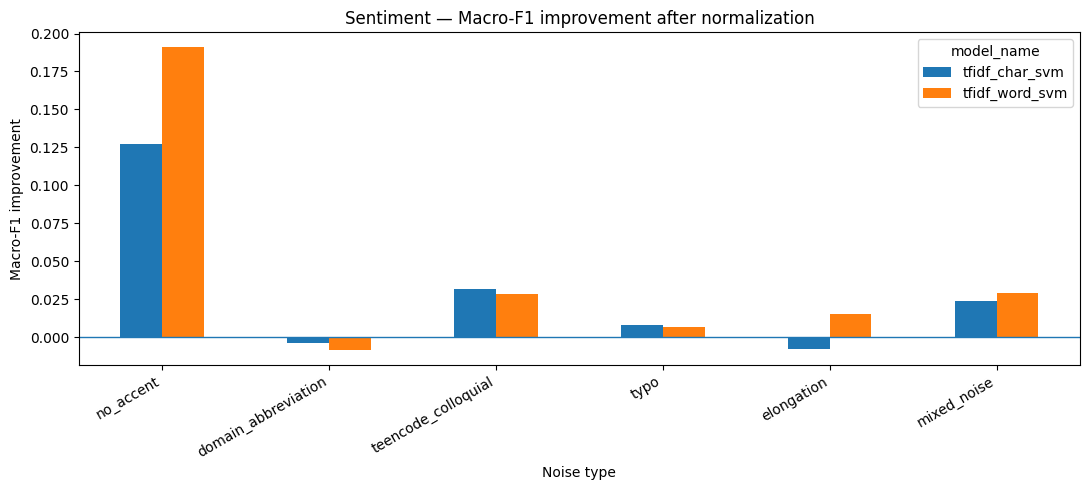

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\08_macro_f1_improvement_by_noise_type_sentiment.png


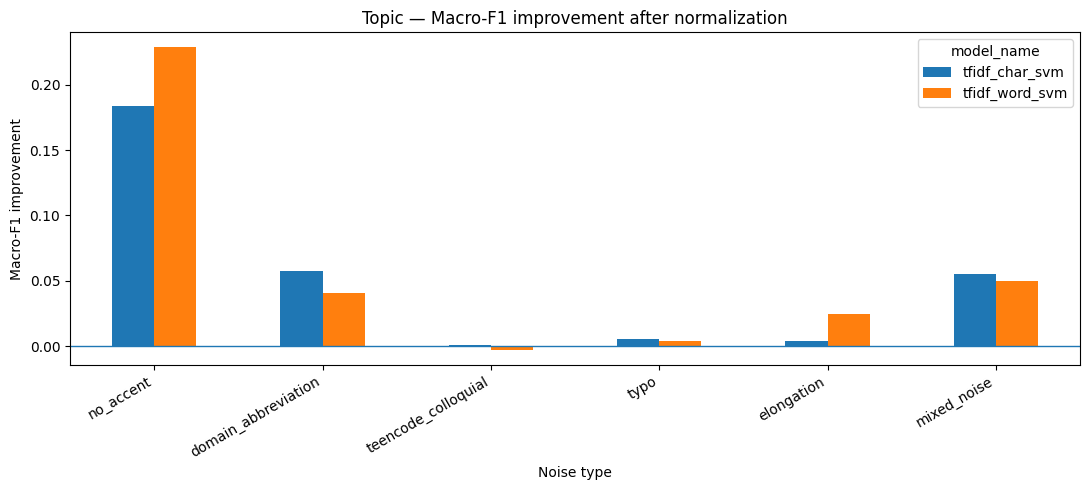

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\08_macro_f1_improvement_by_noise_type_topic.png


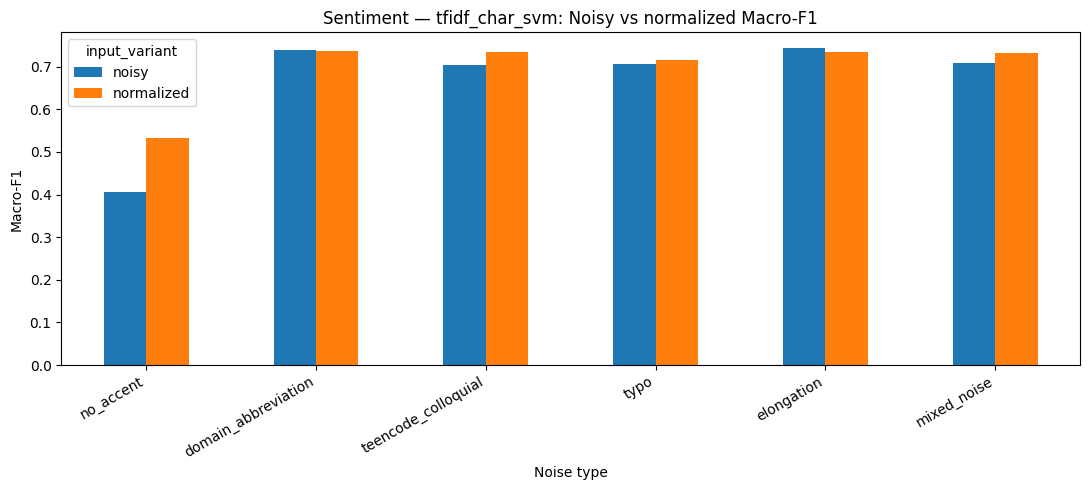

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\08_noisy_vs_normalized_macro_f1_sentiment_tfidf_char_svm.png


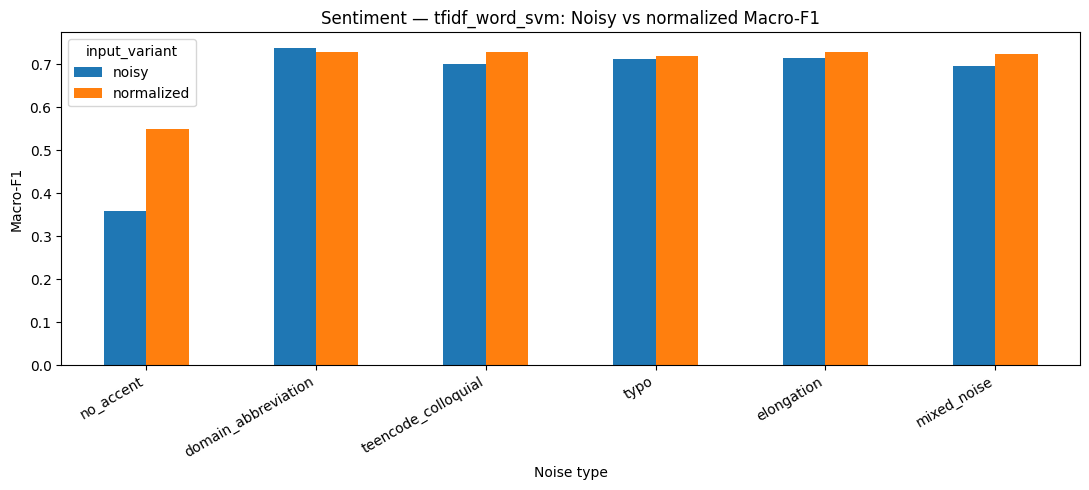

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\08_noisy_vs_normalized_macro_f1_sentiment_tfidf_word_svm.png


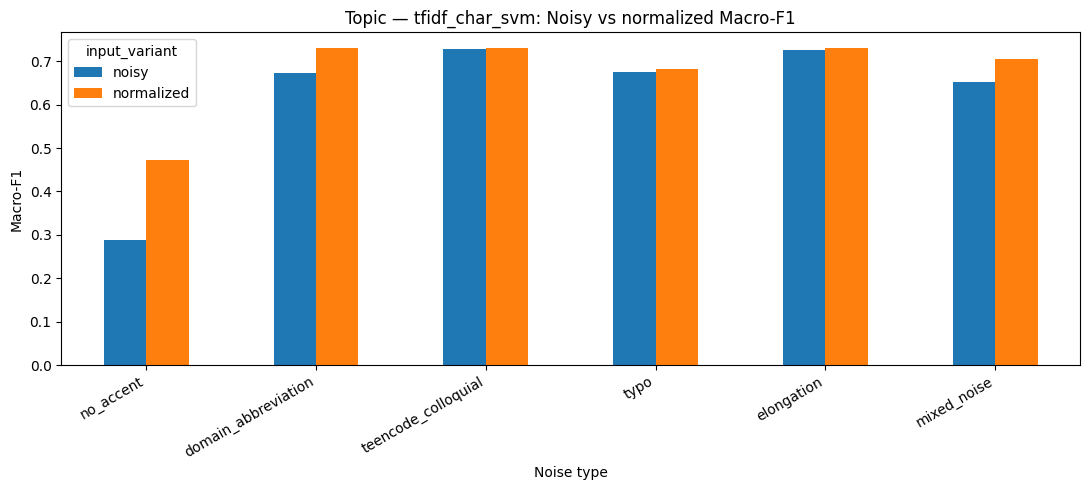

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\08_noisy_vs_normalized_macro_f1_topic_tfidf_char_svm.png


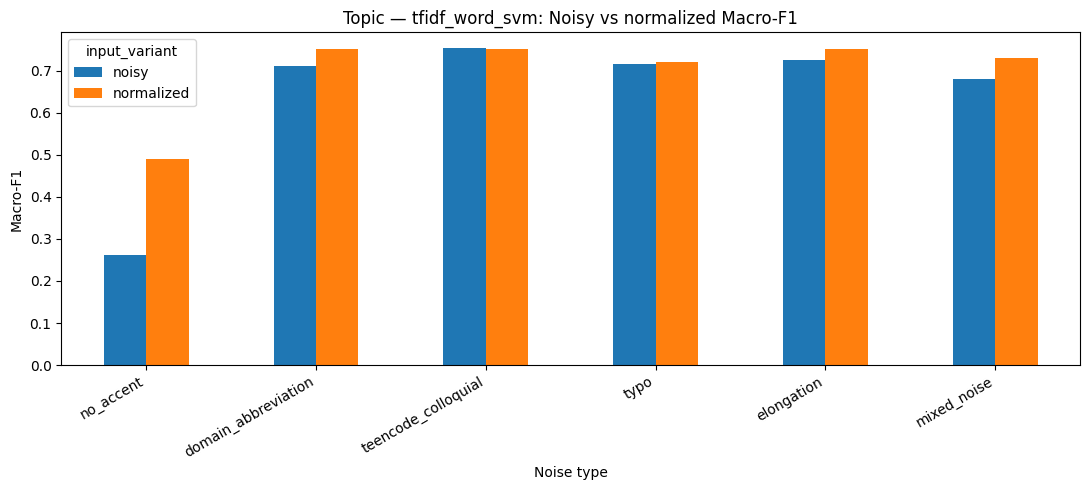

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\08_noisy_vs_normalized_macro_f1_topic_tfidf_word_svm.png


In [8]:
for task in tasks:
    task_df = improvement_df[
        (improvement_df["task"] == task)
        & (improvement_df["evaluation_scope"] == "full")
        & (improvement_df["model_name"] != "majority_class")
    ].copy()

    if task_df.empty:
        continue

    pivot = task_df.pivot_table(
        index="noise_type",
        columns="model_name",
        values="macro_f1_improvement",
        aggfunc="mean",
    )

    order = [
        "no_accent",
        "domain_abbreviation",
        "teencode_colloquial",
        "typo",
        "elongation",
        "mixed_noise",
    ]
    available_order = [item for item in order if item in pivot.index]
    pivot = pivot.loc[available_order]

    ax = pivot.plot(kind="bar", figsize=(11, 5))
    ax.set_title(f"{task.capitalize()} — Macro-F1 improvement after normalization")
    ax.set_xlabel("Noise type")
    ax.set_ylabel("Macro-F1 improvement")
    plt.axhline(0, linewidth=1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    fig_path = FIGURES_DIR / f"08_macro_f1_improvement_by_noise_type_{task}.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()

    print("Saved:", fig_path)

for task in tasks:
    task_eval = normalization_eval_df[
        (normalization_eval_df["task"] == task)
        & (normalization_eval_df["evaluation_scope"] == "full")
        & (normalization_eval_df["model_name"] != "majority_class")
    ].copy()

    if task_eval.empty:
        continue

    for model_name in sorted(task_eval["model_name"].unique()):
        model_df = task_eval[task_eval["model_name"] == model_name].copy()

        pivot = model_df.pivot_table(
            index="noise_type",
            columns="input_variant",
            values="macro_f1",
            aggfunc="mean",
        )

        order = [
            "no_accent",
            "domain_abbreviation",
            "teencode_colloquial",
            "typo",
            "elongation",
            "mixed_noise",
        ]
        available_order = [item for item in order if item in pivot.index]
        pivot = pivot.loc[available_order]

        ax = pivot.plot(kind="bar", figsize=(11, 5))
        ax.set_title(f"{task.capitalize()} — {model_name}: Noisy vs normalized Macro-F1")
        ax.set_xlabel("Noise type")
        ax.set_ylabel("Macro-F1")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()

        fig_path = FIGURES_DIR / f"08_noisy_vs_normalized_macro_f1_{task}_{model_name}.png"
        plt.savefig(fig_path, dpi=150)
        plt.show()

        print("Saved:", fig_path)


## 8. Generate Stage 8 report

In [9]:
def dataframe_to_markdown(df: pd.DataFrame) -> str:
    if df.empty:
        return "_Empty table_"

    safe_df = df.copy()
    for col in safe_df.columns:
        if pd.api.types.is_float_dtype(safe_df[col]):
            safe_df[col] = safe_df[col].round(4)
        safe_df[col] = safe_df[col].astype(str)

    headers = safe_df.columns.tolist()
    lines = []
    lines.append("| " + " | ".join(headers) + " |")
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for _, row in safe_df.iterrows():
        lines.append("| " + " | ".join(row[col] for col in headers) + " |")
    return "\n".join(lines)

report_lines = []
report_lines.append("# Optional Normalization Experiment Report\n")
report_lines.append(f"- Created at: `{datetime.now().isoformat(timespec='seconds')}`")
report_lines.append("- Stage: `08_optional_normalization`")
report_lines.append("- This stage tests simple rule-based normalization on controlled noisy test sets.")
report_lines.append("- No model is trained in this stage.")
report_lines.append("- This local run evaluates baseline TF-IDF/SVM models. PhoBERT normalization evaluation can be run separately on GPU if needed.\n")

report_lines.append("## Normalization rules\n")
report_lines.append("- Reduce elongation, e.g. repeated characters length >= 3.")
report_lines.append("- Expand domain abbreviations such as `gv`, `sv`, `csvc`, `ctdt`.")
report_lines.append("- Expand teencode/colloquial forms such as `ko`, `k`, `dc`, `đc`, `lun`.")
report_lines.append("- Restore a limited set of no-accent Vietnamese phrases.")
report_lines.append("- Correct a small set of common typo forms.\n")

report_lines.append("## Normalization generation summary\n")
report_lines.append(dataframe_to_markdown(normalization_generation_summary))
report_lines.append("\n")

report_lines.append("## Macro-F1 improvement summary, full scope\n")
full_improvement = improvement_df[
    improvement_df["evaluation_scope"] == "full"
][[
    "task",
    "model_name",
    "noise_type",
    "noisy_macro_f1",
    "normalized_macro_f1",
    "macro_f1_improvement",
    "num_eval_samples",
]]
report_lines.append(dataframe_to_markdown(full_improvement))
report_lines.append("\n")

report_lines.append("## Interpretation notes\n")
report_lines.append("- Positive improvement means normalized input performs better than noisy input.")
report_lines.append("- Negative improvement means normalization hurt performance.")
report_lines.append("- No-accent normalization is intentionally limited; it cannot fully restore Vietnamese accents.")
report_lines.append("- Results should be interpreted as an optional recovery experiment, not as a new robust model.\n")

report_lines.append("## Limitations\n")
report_lines.append("- The normalizer is rule-based and incomplete.")
report_lines.append("- Some replacements may be context-insensitive.")
report_lines.append("- PhoBERT normalization evaluation is not included in this local baseline run.")
report_lines.append("- The noisy data is rule-generated and not fully human-validated.\n")

report_path = NOTES_DIR / "08_optional_normalization_report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")

print("Saved:", report_path)


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\notes\08_optional_normalization_report.md


## 9. Final Stage 8 output check

In [10]:
expected_files = [
    TABLES_DIR / "08_normalization_generation_summary.csv",
    TABLES_DIR / "08_normalization_examples.csv",
    TABLES_DIR / "08_baseline_normalization_evaluation.csv",
    TABLES_DIR / "08_baseline_normalization_classification_reports.csv",
    TABLES_DIR / "08_normalization_improvement_summary.csv",
    TABLES_DIR / "08_normalization_improvement_sentiment.csv",
    TABLES_DIR / "08_normalization_improvement_topic.csv",
    FIGURES_DIR / "08_macro_f1_improvement_by_noise_type_sentiment.png",
    FIGURES_DIR / "08_macro_f1_improvement_by_noise_type_topic.png",
    NOTES_DIR / "08_optional_normalization_report.md",
]

print("Stage 8 output check:")
all_ok = True
for path in expected_files:
    exists = path.exists()
    all_ok = all_ok and exists
    print("[OK]     " if exists else "[MISSING]", path)

print("\nStage 8 completed:", all_ok)


Stage 8 output check:
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\08_normalization_generation_summary.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\08_normalization_examples.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\08_baseline_normalization_evaluation.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\08_baseline_normalization_classification_reports.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\08_normalization_improvement_summary.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\08_normalization_improvement_sentiment.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\08_normalization_improvement_topic.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\08_macro_f1_improvement_by_noise_type_sentiment.pn

## What to send for review

Gửi các file:

```text
reports/tables/08_normalization_generation_summary.csv
reports/tables/08_normalization_improvement_summary.csv
reports/tables/08_normalization_examples.csv
reports/notes/08_optional_normalization_report.md
```

Không cần gửi `08_baseline_normalization_predictions.csv` nếu file lớn.
